In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
titanic = sns.load_dataset("titanic")

In [7]:
titanic.head()
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [8]:
features = ["pclass", "sex","fare", "embarked", "age"]
target = ["survived"]

In [10]:
# missing data
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
titanic[["age"]]= imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [12]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [14]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

titanic["sex"]= le.fit_transform(titanic[["sex"]])

titanic["embarked"] = le.fit_transform(titanic[["embarked"]])

c:\Users\91995\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\91995\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [18]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [19]:
x = titanic[features]
y = titanic[target]

In [21]:
y.head()

,survived
0,0
1,1
2,1
3,1
4,0


In [22]:
x_train, x_test, y_train, y_test = train_test_split(
    x , y, test_size=0.2, random_state=42
)

In [24]:
# Decision Tree Model - no pruning
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(x_train, y_train)

DecisionTreeClassifier()

In [25]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(x_test)

print("accuracy : ", accuracy_score(y_test, y_pred))


accuracy :  0.770949720670391


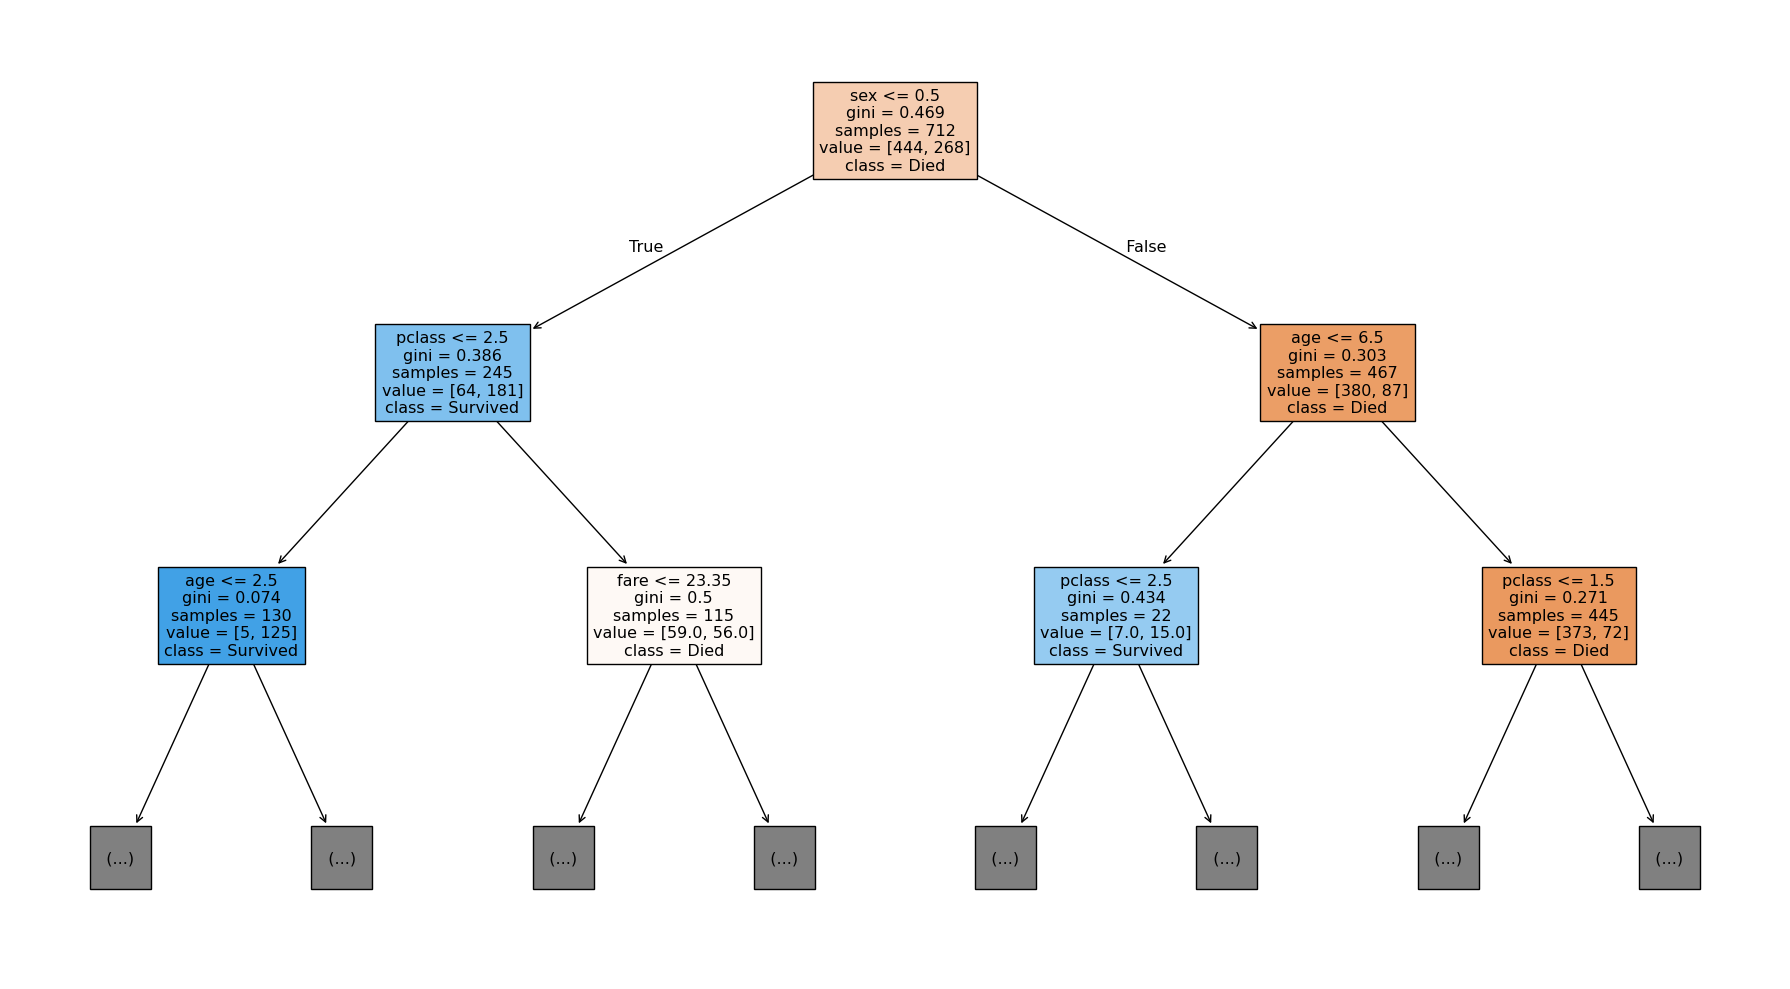

In [27]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=x.columns,
    class_names=["Died", "Survived"],
    filled=True,
    max_depth=2
)

plt.tight_layout()
plt.show()

### Decision Tree with pre-pruning

In [ ]:
max_depths = [2,3,4,5,6,7,8,9,10]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth= depth)
    model.fit(x_train, y_train)

    acc = model.score(x_test, y_test)
    print(f"for depth={depth}, accuracy= {acc}")

    

for depth=2, accuracy= 0.7653631284916201
for depth=3, accuracy= 0.7988826815642458
for depth=4, accuracy= 0.7988826815642458
for depth=5, accuracy= 0.7988826815642458
for depth=6, accuracy= 0.8044692737430168
for depth=7, accuracy= 0.7877094972067039
for depth=8, accuracy= 0.7877094972067039
for depth=9, accuracy= 0.7877094972067039
for depth=10, accuracy= 0.7988826815642458


In [32]:
min_samples_splits = [5, 10, 15, 20, 25, 30]

for split in min_samples_splits:
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(x_train, y_train)

    acc = model.score(x_test, y_test)
    print(f"for sample split={split}, accuracy={acc}")

for sample split=5, accuracy=0.7988826815642458
for sample split=10, accuracy=0.7988826815642458
for sample split=15, accuracy=0.7988826815642458
for sample split=20, accuracy=0.7988826815642458
for sample split=25, accuracy=0.7932960893854749
for sample split=30, accuracy=0.7932960893854749


### Decision Tree with Post Pruning

In [33]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [34]:
path = full_tree.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [35]:
# train our model for all alphas

trees = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(x_train, y_train)

    trees.append((model, alpha))


In [36]:
best_acc = 0
best_alpha = 0

for model, alpha in trees:
    curr_acc = model.score(x_test, y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [38]:
best_acc

0.8379888268156425

In [42]:
best_model = DecisionTreeClassifier(ccp_alpha = best_alpha)
best_model.fit(x_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.0015407231242023183)

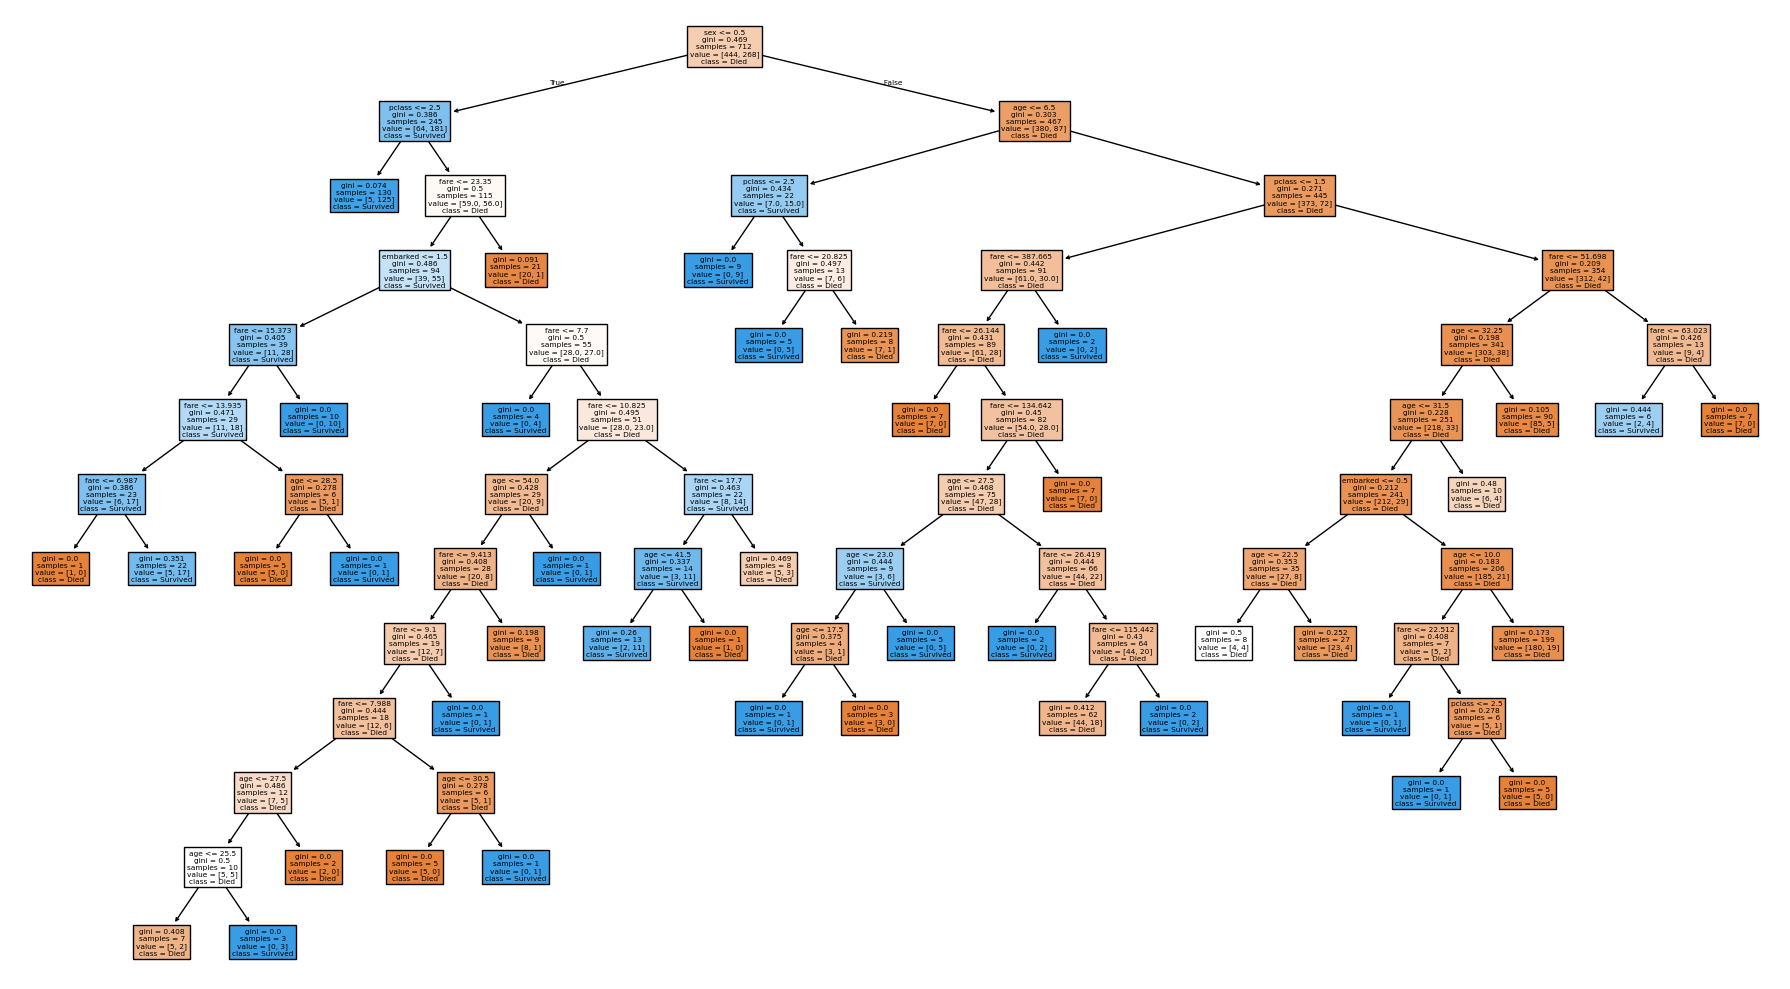

In [44]:
plt.figure(figsize=(18, 10))

plot_tree(
    best_model,
    feature_names=x.columns,
    class_names=["Died", "Survived"],
    filled=True
)

plt.tight_layout()
plt.show()